# Análise Descritiva, KPIs e Preparação da Base

**Contexto:** a base é uma simulação de Monte Carlo com 1.200 cenários (futuros financeiros possíveis) para uma mesma empresa concessionária de infraestrutura, ao longo de 12 anos (Ano 1 = 2027 ... Ano 12 = 2038, ano de encerramento da concessão). Todos os valores são projeções — não há dados históricos reais.

**Estrutura deste notebook:**
1. Configuração e carga dos dados brutos
2. Perfil e qualidade dos dados (RF03)
3. Limpeza e transformação (RF04)
4. Checagens de consistência (validação da base inteira)
5. Cálculo dos KPIs financeiros (RF08)
6. Análise descritiva — medidas de posição e dispersão (RF06)
7. Percentis (P5/P10/P50/P90/P95) — conforme orientação da CTI
8. Visualizações — histogramas e boxplots (RF06)
9. Classificação dos cenários (rascunho inicial, 6 categorias sugeridas pela CTI)
10. Perspectivas de stakeholder (CFO, acionistas, credores, poder concedente) — início

> Este notebook assume que o arquivo Dados_Originais_CTI.csv (https://github.com/2026-2-NCC4/Projeto10/blob/main/data/raw/Dados_Originais_CTI.csv) está na mesma pasta (ou ajuste `CAMINHO_ARQUIVO` abaixo, ex: para o Google Drive montado no Colab).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Configuração e carga dos dados brutos

In [2]:
# Leitura do CSV bruto
# - sem cabeçalho (header=None) -> nomeamos as 4 colunas manualmente
# - encoding ISO-8859-1 (Latin-1), conforme identificado na inspeção do arquivo
# - separador ';'
# - números em formato brasileiro: ponto = milhar, vírgula = decimal

CAMINHO_ARQUIVO = "Dados_Originais_CTI.csv"

df_raw = pd.read_csv(
    CAMINHO_ARQUIVO,
    sep=";",
    header=None,
    names=["Ano", "Cenário", "Conta", "Valores"],
    encoding="latin-1",
    decimal=",",
    thousands=".",
    dtype={"conta": str},
)

print("Dimensões:", df_raw.shape)
df_raw.head(10)

Dimensões: (1002000, 4)


,Ano,Cenário,Conta,Valores
0,Ano 1,Total Cen_00001,NaN,3.000000e-02
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09
3,Ano 1,Total Cen_00001,BAL - Disponível,1.205265e+09
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,5.846615e+05
6,Ano 1,Total Cen_00001,BAL - Contas a Receber - Clientes,4.538710e+08
7,Ano 1,Total Cen_00001,BAL - Estoques Diversos,8.662079e+04
8,Ano 1,Total Cen_00001,BAL - Outros Créditos,4.023325e+07
9,Ano 1,Total Cen_00001,BAL - Realizável a Longo Prazo,6.390239e+08


## 2. Perfil e qualidade dos dados brutos (RF03)

Aqui vamos fazer um primeiro reconhecimento da base, antes de confiar em qualquer número dela. A pergunta: **os dados batem com o que a CTI descreveu (1.200 cenários, 12 anos, contas financeiras), ou já aparecem inconsistências logo de cara** (linhas duplicadas, tipos de dado errados, contagens diferentes do esperado)?

In [3]:
print("Tipos de dado:")
print(df_raw.dtypes)
print()
print("Valores únicos por coluna:")
print("  ano:", df_raw['Ano'].nunique(), "->", sorted(df_raw['Ano'].unique(), key=lambda x: int(x.split()[1])))
print("  cenario:", df_raw['Cenário'].nunique())
print("  conta:", df_raw['Conta'].nunique(), "(inclui linhas de metadado com conta vazia)")
print()
print("Linhas com 'Conta' vazia (metadado, não é conta financeira):", df_raw['Conta'].isna().sum())
print("Linhas totais:", len(df_raw))
print("Duplicidade exata de linha inteira:", df_raw.duplicated().sum())

Tipos de dado:
Ano         object
Cenário     object
Conta       object
Valores    float64
dtype: object

Valores únicos por coluna:
  ano: 12 -> ['Ano 1', 'Ano 2', 'Ano 3', 'Ano 4', 'Ano 5', 'Ano 6', 'Ano 7', 'Ano 8', 'Ano 9', 'Ano 10', 'Ano 11', 'Ano 12']
  cenario: 1200
  conta: 69 (inclui linhas de metadado com conta vazia)

Linhas com 'Conta' vazia (metadado, não é conta financeira): 43200
Linhas totais: 1002000
Duplicidade exata de linha inteira: 14400


### Análise: os nomes das contas estão escritos de forma consistente?

Mais adiante vamos agrupar e comparar dados usando o nome da conta como referência. Aqui checamos se isso é seguro de fazer: **se o mesmo nome de conta aparecer escrito de duas formas diferentes (ex: espaçamento diferente), o Python trataria como contas diferentes**, e cálculos e agrupamentos sairiam errados sem gerar nenhum erro visível.

In [4]:
# Padronização encontrada na inspeção manual: 9 contas do grupo Patrimônio Líquido
# têm DOIS espaços após 'BAL' (ex.: 'BAL  - Patrimônio Líquido'), as demais têm um espaço só.
# Isso quebraria qualquer agrupamento por nome de conta se não for corrigido.
contas_com_espaco_duplo = df_raw.loc[df_raw['Conta'].str.contains('  ', na=False), 'Conta'].unique()
print(f"{len(contas_com_espaco_duplo)} contas com espaçamento inconsistente encontradas:")
for c in contas_com_espaco_duplo:
    print(" -", repr(c))

0 contas com espaçamento inconsistente encontradas:


## 3. Limpeza e transformação (RF04)

Aqui vamos corrigir o problema de espaçamento encontrado na etapa anterior, e separar as linhas que não são contas financeiras (as de metadado) do restante da base — elas têm um significado diferente e não devem ser misturadas com os valores de Balanço, DRE e Fluxo de Caixa.

Passos:
1. Padronizar nomes de conta (remover espaços duplicados)
2. Separar as linhas de metadado (conta vazia) da tabela principal de contas financeiras
3. Pivotar o formato longo (uma linha por conta) para o formato largo (uma coluna por conta) — uma linha por (ano, cenário)
4. Criar colunas auxiliares: ano numérico, ano calendário (convenção: Ano 1 = 2027), flag de encerramento da concessão (Ano 12)


In [5]:
df = df_raw.copy()

# 3.1 Padronizar nomes de conta
df['Conta'] = df['Conta'].str.replace(r'\s+', ' ', regex=True).str.strip()

# 3.2 Separar metadados (conta vazia) da tabela de contas
meta = df[df['Conta'].isna()].copy()
contas_df = df[df['Conta'].notna()].copy()

print("Linhas de conta financeira:", len(contas_df))
print("Linhas de metadado:", len(meta))

Linhas de conta financeira: 958800
Linhas de metadado: 43200


### Análise: o que representam as linhas de metadado?

Essas linhas aparecem 3 vezes por combinação ano+cenário, mas ainda não sabemos seu significado exato. A pergunta: **elas têm um padrão reconhecível (ex: sempre o mesmo valor, ou um valor que varia de forma consistente) que ajude a identificar o que representam?**

In [6]:
# 3.3 As linhas de metadado vêm em grupos de 3 por (ano, cenário).
# Achado da inspeção: a 1ª tem um valor ~2,5% que varia ano a ano (e fica negativo no Ano 12) —
#   hipótese mais provável: é o índice macro (ex.: IPCA) daquele cenário/ano, NÃO uma probabilidade
#   fixa por cenário (uma probabilidade não variaria de forma consistente por ano).
# A confirmar com a CTI!
# As outras 2 são sempre zero em toda a base (checado abaixo) — provavelmente linhas reservadas/sem uso.
meta['ordem'] = meta.groupby(['Ano', 'Cenário']).cumcount()
meta_wide = meta.pivot_table(index=['Ano', 'Cenário'], columns='ordem', values='Valores', aggfunc='first')
meta_wide.columns = ['meta_indice_macio_hipotese', 'meta_zero_1', 'meta_zero_2']

print("As duas colunas 'zero' são realmente sempre zero?")
print("  meta_zero_1 - max abs:", meta_wide['meta_zero_1'].abs().max())
print("  meta_zero_2 - max abs:", meta_wide['meta_zero_2'].abs().max())
meta_wide.head()

As duas colunas 'zero' são realmente sempre zero?
  meta_zero_1 - max abs: 0.0
  meta_zero_2 - max abs: 0.0


meta_indice_macio_hipotese  meta_zero_1  meta_zero_2
Ano   Cenário                                                              
Ano 1 Total Cen_00001                        0.03          0.0          0.0
      Total Cen_00002                        0.03          0.0          0.0
      Total Cen_00003                        0.03          0.0          0.0
      Total Cen_00004                        0.03          0.0          0.0
      Total Cen_00005                        0.03          0.0          0.0

### Análise: montando a base analítica final

Aqui vamos transformar a base do formato "uma linha por conta" para "uma linha por cenário e ano, com uma coluna para cada conta" — é o formato necessário para calcular KPIs, já que cada cálculo financeiro combina várias contas na mesma linha (ex: Receita e Custos juntas para calcular margem).

In [7]:
# 3.4 Pivotar para formato largo: uma coluna por conta financeira
wide = contas_df.pivot_table(index=['Ano', 'Cenário'], columns='Conta', values='Valores', aggfunc='first')
wide = wide.join(meta_wide, on=['Ano', 'Cenário']).reset_index()

# 3.5 Colunas auxiliares de ano
wide['ano_num'] = wide['Ano'].str.extract(r'(\d+)').astype(int)
wide['ano_calendario'] = wide['ano_num'] + 2026  # convenção CTI: Ano 1 = 2027
wide['encerramento_concessao'] = wide['ano_num'] == 12

print("Base analítica final:", wide.shape[0], "linhas (1.200 cenários x 12 anos) x", wide.shape[1], "colunas")
wide.head(3)

Base analítica final: 14400 linhas (1.200 cenários x 12 anos) x 77 colunas


,Ano,Cenário,BAL - Amortização - Intangível,BAL - Amortização Acumulada,BAL - At Fiscal Diferido,BAL - Ativo Circulante,BAL - Capital Social,BAL - Contas a Pagar - Parte Relacionada,BAL - Contas a Receber - Clientes,BAL - Contas a Receber - Partes Relacionadas,...,FLU - Resultado Financeiro,FLU - Saldo Final,FLU - Saldo Inicial,FLU - Tributos,meta_indice_macio_hipotese,meta_zero_1,meta_zero_2,ano_num,ano_calendario,encerramento_concessao
0,Ano 1,Total Cen_00001,-5.047124e+09,-30111275.81,-1.039693e+08,1.795721e+09,-309618939.0,-14086270.7,4.538710e+08,584661.47,...,-7.304044e+08,1.205265e+09,7.746152e+08,-4.732576e+08,0.03,0.0,0.0,1,2027,False
1,Ano 1,Total Cen_00002,-5.047124e+09,-29981503.82,-1.036850e+08,1.789812e+09,-309618939.0,-14086270.7,4.538710e+08,584661.47,...,-7.256803e+08,1.198931e+09,7.746152e+08,-4.718228e+08,0.03,0.0,0.0,1,2027,False
2,Ano 1,Total Cen_00003,-5.047124e+09,-29837332.16,-1.036096e+08,1.790756e+09,-309618939.0,-14086270.7,4.538710e+08,584661.47,...,-7.083835e+08,1.195792e+09,7.746152e+08,-4.697783e+08,0.03,0.0,0.0,1,2027,False


## 4. Checagens de consistência (qualidade — base inteira)

Aqui vamos testar se a base é internamente consistente, aplicando identidades contábeis que deveriam ser sempre verdadeiras (Ativo = Passivo + Patrimônio Líquido) e a relação esperada entre EBIT e EBITDA. A pergunta: **os números fecham em todos os 1.200 cenários e 12 anos, ou existem inconsistências que precisamos entender antes de confiar nos KPIs calculados a partir deles?**

**Atenção à convenção de sinais da base:** os valores de Ativo vêm positivos, mas Passivo e Patrimônio Líquido vêm **negativos**. A identidade correta aqui é `Total do Ativo + Total do Passivo ≈ 0` (o "Total do Passivo" já soma Passivo Circulante + Exigível LP + Patrimônio Líquido).

In [8]:
# Checagem 1: Ativo + Passivo ≈ 0
wide['check_identidade_bal'] = wide['BAL - Total do Ativo'] + wide['BAL - Total do Passivo']

# Checagem 2: Total do Passivo = Passivo Circulante + Exigível LP + Patrimônio Líquido
wide['check_passivo_composicao'] = wide['BAL - Total do Passivo'] - (
    wide['BAL - Passivo Circulante'] + wide['BAL - Exigível a Longo Prazo'] + wide['BAL - Patrimônio Líquido']
)

# Checagem 3: EBIT (Resultado Operacional) vs EBITDA - D&A
# ATENÇÃO: este check NÃO fecha em zero na base (ver observação abaixo) — resultado documentado, não escondido.
wide['check_ebit_vs_ebitda'] = wide['DRE - Resultado Operacional'] - (
    wide['DRE - EBITDA'] + wide['DRE - Depreciação e Amortização']
)

resumo_checks = wide.groupby('ano_num')[['check_identidade_bal', 'check_passivo_composicao', 'check_ebit_vs_ebitda']].agg(['mean', 'std'])
resumo_checks

check_identidade_bal           check_passivo_composicao            \
                        mean       std                     mean       std   
ano_num                                                                     
1                   0.025542  0.004973                -0.004308  0.005004   
2                   0.025450  0.004982                -0.004033  0.004942   
3                   0.024775  0.004997                -0.003700  0.004864   
4                   0.025550  0.004972                -0.003742  0.004841   
5                   0.024675  0.004991                -0.004608  0.005037   
6                   0.025433  0.004983                -0.003659  0.004938   
7                   0.025400  0.004986                -0.003950  0.004941   
8                   0.024733  0.004995                -0.001167  0.004949   
9                   0.024742  0.004995                 0.001050  0.004805   
10                  0.024550  0.004982                 0.000325  0.005553   
11                  0.025175  0.004999                 0.002417  0.004900   
12                 -0.025775  0.004942                      NaN       NaN   

        check_ebit_vs_ebitda                
                        mean           std  
ano_num                                     
1              -2.968723e+08  9.067236e+05  
2              -3.502263e+08  1.870487e+06  
3              -3.900080e+08  2.994882e+06  
4              -4.279720e+08  4.483795e+06  
5              -3.197715e+08  3.686349e+06  
6              -3.229616e+08  4.521837e+06  
7              -4.393621e+08  8.273510e+06  
8              -4.826176e+08  1.077561e+07  
9              -5.266534e+08  1.338425e+07  
10             -3.854106e+08  9.581256e+06  
11             -1.288848e+08  3.658606e+05  
12             -1.538399e+09  6.024845e-03

**Leitura dos resultados:**
- `check_identidade_bal` e `check_passivo_composicao`: ficam em torno de R$0,00–0,03 em todos os anos — ruído de arredondamento, a identidade se confirma em toda a base.
- `check_ebit_vs_ebitda`: **não fica perto de zero** (varia de ~R$ -130 milhões a ~R$ -1,5 bilhão dependendo do ano) — ou seja, `EBITDA ≠ EBIT + D&A` nesta base. Há algum outro componente na composição do EBITDA que não está explícito nas 69 contas disponíveis (possivelmente ligado ao tratamento contábil específico de concessões — ICPC 01). **Registrar como limitação e levar à CTI antes de comparar EBIT/EBITDA entre cenários.**


### Análise: os dados ausentes são erro ou característica do negócio?

Aqui vamos investigar onde faltam dados na base e se isso segue um padrão. A pergunta: **os valores ausentes são um problema de qualidade, ou refletem algo real do negócio** (por exemplo, contas que deixam de existir no ano de encerramento da concessão)?

In [9]:
# Valores ausentes por conta, e em qual ano se concentram
ausentes = wide.isna().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)

print("Colunas com valores ausentes:")
print(ausentes)
print()

for col in ausentes.index[:5]:
    anos_com_ausencia = wide[wide[col].isna()]['ano_num'].unique()
    print(f"  '{col}' ausente no(s) ano(s): {sorted(anos_com_ausencia)}")

Colunas com valores ausentes:
BAL - Dividendos Antecipados                    3600
BAL - Amortização Acumulada                     1200
BAL - Contas a Pagar - Parte Relacionada        1200
BAL - Capital Social                            1200
BAL - Contas a Receber - Partes Relacionadas    1200
BAL - Contas a Receber - SWAP                   1200
BAL - Créditos Tributários                      1200
BAL - Diferido                                  1200
BAL - Emprést                                   1200
BAL - Encargos Sociais e Trabalhistas           1200
BAL - Estoques Diversos                         1200
BAL - Exigível a Longo Prazo                    1200
BAL - Fornecedores                              1200
BAL - Obrigações com o Poder Concedente         1200
BAL - Outorga da Concessão                      1200
BAL - Outros Créditos LP                        1200
BAL - Outros Débitos                            1200
BAL - Outros deb                                1200
BAL - Patrimônio

**Leitura:** os valores ausentes se concentram quase todos no **Ano 12** (Exigível a Longo Prazo, Capital Social, Contas a Receber de Partes Relacionadas somem nesse ano) — coerente com a explicação da CTI: no encerramento da concessão, ativos são devolvidos, dívidas liquidadas e contas zeradas/encerradas. **Não tratar como erro de dados** — é característica do negócio. `BAL - Dividendos Antecipados` também falta nos Anos 1 e 2 (plausível: sem distribuição antecipada logo no início da operação).

## 5. Cálculo dos KPIs financeiros (RF08)

Aqui vamos calcular, para cada uma das 14.400 combinações de ano e cenário, os indicadores financeiros (rentabilidade, endividamento, liquidez) que vão sustentar toda a análise seguinte. Esta etapa ainda não interpreta nenhum resultado — só aplica as fórmulas já validadas com o Prof Mauricio - Contabilidade e Finanças, para termos os KPIs prontos para as próximas seções.

Decisões já registradas no Dicionário de KPIs (entrega 1 do Maurício):
- Custos tratados integralmente como variáveis (limitação documentada)
- `BAL - Empréstimos` tratado como dívida de curto prazo, `BAL - Emprést` como longo prazo (hipótese pela posição no arquivo original)


In [10]:
w = wide.copy()

# Rentabilidade
w['margem_ebitda'] = w['DRE - EBITDA'] / w['DRE - Receita']
w['margem_ebit'] = w['DRE - Resultado Operacional'] / w['DRE - Receita']
w['margem_liquida'] = w['DRE - Resultado Líquido'] / w['DRE - Receita']
w['roa'] = w['DRE - Resultado Líquido'] / w['BAL - Total do Ativo']
w['roe'] = w['DRE - Resultado Líquido'] / w['BAL - Patrimônio Líquido'].abs()

# Endividamento
w['divida_bruta'] = w['BAL - Empréstimos'].abs() + w['BAL - Emprést'].abs()
w['divida_liquida'] = w['divida_bruta'] - w['BAL - Disponível']
w['divida_liquida_ebitda'] = w['divida_liquida'] / w['DRE - EBITDA']
w['endividamento_geral'] = (w['BAL - Passivo Circulante'].abs() + w['BAL - Exigível a Longo Prazo'].abs()) / w['BAL - Total do Ativo']
w['grau_alavancagem'] = (w['BAL - Passivo Circulante'].abs() + w['BAL - Exigível a Longo Prazo'].abs()) / w['BAL - Patrimônio Líquido'].abs()

# Liquidez (ATENÇÃO: instável/não interpretável no Ano 12 — ver seção 8)
w['capital_giro'] = w['BAL - Ativo Circulante'] - w['BAL - Passivo Circulante'].abs()
w['liquidez_corrente'] = w['BAL - Ativo Circulante'] / w['BAL - Passivo Circulante'].abs()
w['liquidez_imediata'] = w['BAL - Disponível'] / w['BAL - Passivo Circulante'].abs()

# Conferência rápida contra a planilha de validação (Ano 1, Cenário 1)
exemplo = w[(w['ano_num'] == 1) & (w['Cenário'] == 'Total Cen_00001')]
cols_check = ['margem_ebitda', 'roa', 'roe', 'liquidez_corrente', 'divida_liquida_ebitda']
exemplo[cols_check]

,margem_ebitda,roa,roe,liquidez_corrente,divida_liquida_ebitda
0,0.771767,0.22982,1.212867,1.661277,0.910321


## 6. Análise descritiva — medidas de posição e dispersão (RF06)

Medidas de posição (média, mediana) e dispersão (desvio-padrão, mínimo, máximo) para os principais KPIs, por ano, entre os 1.200 cenários.

Aqui vamos resumir, para cada KPI principal e cada ano, como os 1.200 cenários se distribuem em conjunto. A pergunta: **qual é o valor típico de cada KPI em cada ano, e o quanto ele varia entre os cenários? Essa variação aumenta, diminui ou se mantém estável ao longo dos 12 anos da concessão?**

In [11]:
kpis_principais = ['margem_ebitda', 'margem_liquida', 'roa', 'roe', 'endividamento_geral', 'liquidez_corrente']

for kpi in kpis_principais:
    print(f"\n{kpi}")
    display(w.groupby('ano_num')[kpi].agg(['mean', 'median', 'std', 'min', 'max']).round(4))


margem_ebitda


,mean,median,std,min,max
ano_num,,,,,
1,0.7714,0.7713,0.0006,0.7668,0.7751
2,0.7579,0.7579,0.0010,0.7511,0.7645
3,0.7828,0.7831,0.0014,0.7761,0.7905
4,0.7935,0.7938,0.0018,0.7860,0.8028
5,0.7994,0.7997,0.0021,0.7910,0.8103
6,0.8052,0.8055,0.0022,0.7959,0.8166
7,0.8108,0.8111,0.0023,0.8008,0.8230
8,0.8144,0.8147,0.0024,0.8037,0.8273
9,0.8179,0.8181,0.0024,0.8064,0.8309



margem_liquida


,mean,median,std,min,max
ano_num,,,,,
1,0.3617,0.3638,0.0058,0.3400,0.3677
2,0.3230,0.3261,0.0085,0.2875,0.3319
3,0.3379,0.3404,0.0069,0.3022,0.3439
4,0.3534,0.3570,0.0092,0.3076,0.3603
5,0.3849,0.3875,0.0070,0.3443,0.3924
6,0.4071,0.4084,0.0047,0.3724,0.4208
7,0.4094,0.4106,0.0049,0.3716,0.4263
8,0.4160,0.4172,0.0053,0.3748,0.4340
9,0.4248,0.4271,0.0073,0.3743,0.4391



roa


...

,mean,median,std,min,max
ano_num,,,,,
1,1.2159,1.2145,0.0052,1.2095,1.2430
2,1.4099,1.3875,0.0750,1.3322,1.9128
3,1.4810,1.4280,0.1762,1.3280,3.2014
4,1.5128,1.4632,0.1657,1.3716,3.1308
5,1.5839,1.4869,0.4404,1.2529,9.5332
6,1.7415,1.4913,2.7349,1.1149,69.5153
7,2.0636,1.4667,15.0563,0.9674,521.7580
8,1.6482,1.4434,1.9933,0.8530,60.5634
9,1.6519,1.4179,2.6959,0.7590,88.4682



endividamento_geral


,mean,median,std,min,max
ano_num,,,,,
1,0.8126,0.8116,0.0035,0.8080,0.8300
2,0.8640,0.8614,0.0088,0.8537,0.9129
3,0.8656,0.8616,0.0126,0.8428,0.9450
4,0.8394,0.8345,0.0150,0.8122,0.9390
5,1.0770,1.0924,0.0438,0.9111,1.1375
6,1.2501,1.2694,0.0557,0.9747,1.3173
7,1.3800,1.3940,0.0489,1.0530,1.4707
8,1.3165,1.3222,0.0359,0.9927,1.5148
9,1.4277,1.4173,0.0827,0.9723,1.9116



liquidez_corrente


,mean,median,std,min,max
ano_num,,,,,
1,1.5831,1.6510,0.1703,1.0546,1.6922
2,1.0518,1.1403,0.2220,0.3590,1.1995
3,1.2173,1.2990,0.2027,0.4403,1.3465
4,3.0792,3.3777,0.7185,0.6760,3.4710
5,0.7580,0.6683,0.9061,0.4190,25.2048
6,0.4699,0.4014,1.4894,0.2642,50.8690
7,0.4014,0.3776,0.5267,0.2196,16.6551
8,0.7337,0.7401,0.2761,0.2949,8.3999
9,0.7264,0.7585,0.2009,0.1093,3.5235


### Análise: existe um valor que se repete mais entre os cenários?

Aqui vamos verificar se existe uma faixa de valor que concentra mais cenários que as demais, complementando a média e a mediana já calculadas. Como os KPIs são contínuos (dificilmente dois cenários têm o valor exatamente igual), arredondamos antes de calcular a moda, para identificar concentrações de valores próximos.

In [12]:
# Moda (menos comum em dados contínuos, mas pedida no edital) - calculada via arredondamento em faixas
from scipy import stats as sstats

for kpi in ['margem_ebitda', 'liquidez_corrente']:
    moda_por_ano = w.groupby('ano_num')[kpi].apply(lambda x: sstats.mode(x.round(3), keepdims=True).mode[0])
    print(f"Moda aproximada (arredondada) de {kpi} por ano:")
    print(moda_por_ano)
    print()

Moda aproximada (arredondada) de margem_ebitda por ano:
ano_num
1     0.771
2     0.758
3     0.783
4     0.794
5     0.800
6     0.806
7     0.812
8     0.815
9     0.819
10    0.823
11    0.824
12    0.958
Name: margem_ebitda, dtype: float64

Moda aproximada (arredondada) de liquidez_corrente por ano:
ano_num
1      1.173
2      0.516
3      0.734
4      1.333
5      1.029
6      0.440
7      0.281
8      0.508
9      0.355
10     0.223
11     0.296
12    73.090
Name: liquidez_corrente, dtype: float64



## 7. Percentis (P5, P10, P50, P90, P95)

### Análise: qual o pior e o melhor cenário razoável, descartando os extremos?

Diferente da média e do desvio-padrão, os percentis respondem a perguntas sobre as extremidades da distribuição. Aqui vamos calcular P5, P10, P50, P90 e P95 para os KPIs principais, por ano, para responder: **qual é o pior cenário razoável (P5) e o melhor cenário razoável (P95) para cada KPI em cada ano, sem deixar que um único caso extremo domine a leitura?**

In [13]:
percentis = [0.05, 0.10, 0.50, 0.90, 0.95]

tabela_percentis = {}
for kpi in kpis_principais:
    tabela_percentis[kpi] = w.groupby('ano_num')[kpi].quantile(percentis).unstack()
    tabela_percentis[kpi].columns = ['P5', 'P10', 'P50', 'P90', 'P95']

# Exemplo: percentis da margem EBITDA por ano
tabela_percentis['margem_ebitda'].round(4)

,P5,P10,P50,P90,P95
ano_num,,,,,
1,0.7711,0.7711,0.7713,0.7718,0.7720
2,0.7571,0.7573,0.7579,0.7585,0.7587
3,0.7807,0.7812,0.7831,0.7840,0.7844
4,0.7906,0.7912,0.7938,0.7952,0.7956
5,0.7960,0.7967,0.7997,0.8015,0.8020
6,0.8017,0.8025,0.8055,0.8074,0.8081
7,0.8071,0.8079,0.8111,0.8132,0.8139
8,0.8106,0.8115,0.8147,0.8170,0.8177
9,0.8142,0.8150,0.8181,0.8205,0.8213


## 8. Visualizações — histogramas e boxplots (RF06)

### Análise: dispersão da rentabilidade entre os 1.200 cenários (Ano 6)

Aqui vamos analisar como a Margem EBITDA e o ROE se comportam entre os 1.200 cenários simulados, escolhendo o Ano 6 como ponto médio do horizonte da concessão. A pergunta que queremos responder: **o quanto a rentabilidade da empresa varia dependendo do cenário macroeconômico sorteado (cada cenário usa um IPCA diferente)?** Se a distribuição for estreita e concentrada, significa que a rentabilidade é pouco sensível às incertezas simuladas; se for espalhada, significa que o cenário macro importa muito para o resultado da empresa.

**Nota sobre o Ano 12:** a Liquidez Corrente (e outros KPIs que dividem por Passivo Circulante) fica instável no Ano 12, porque o Passivo Circulante vai a quase zero na liquidação da concessão — a divisão gera valores extremos que não são comparáveis aos demais anos. Por isso, nos gráficos de liquidez abaixo, o Ano 12 é tratado separadamente.

In [14]:
def plot_hist(serie, ax, titulo, xlabel, cor='#2E6F5E', bins=40, corte=(0.01, 0.99)):
    """
    Histograma legível: corta 1% de cada cauda só para a VISUALIZAÇÃO
    (os outliers continuam nos dados, só não distorcem a escala do gráfico).
    """
    s = serie.dropna()
    lo, hi = s.quantile(corte[0]), s.quantile(corte[1])
    s_plot = s[(s >= lo) & (s <= hi)]
    n_fora = len(s) - len(s_plot)

    ax.hist(s_plot, bins=bins, color=cor, edgecolor='white', linewidth=0.5)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Nº de cenários')
    ax.grid(alpha=0.3)
    ax.axvline(s.median(), color='crimson', ls='--', lw=1.5,
               label=f'Mediana: {s.median():,.2f}')
    ax.legend(fontsize=8,
              title=f'{n_fora} outlier(s) fora do eixo' if n_fora else None,
              title_fontsize=7)

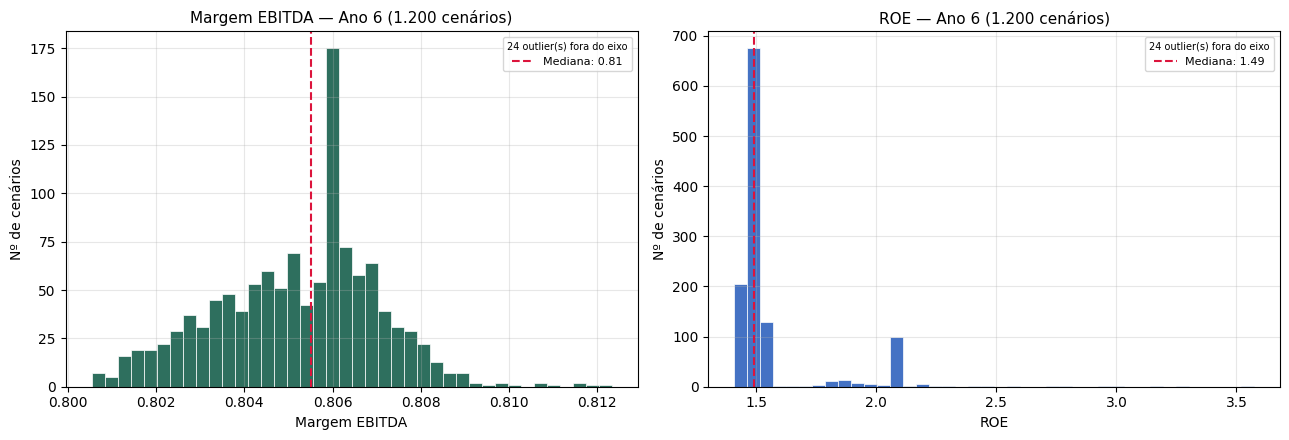

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ano_exemplo = 6

plot_hist(w[w['ano_num'] == ano_exemplo]['margem_ebitda'], axes[0],
          f'Margem EBITDA — Ano {ano_exemplo} (1.200 cenários)', 'Margem EBITDA')
plot_hist(w[w['ano_num'] == ano_exemplo]['roe'], axes[1],
          f'ROE — Ano {ano_exemplo} (1.200 cenários)', 'ROE', cor='#4472C4')

plt.tight_layout()
plt.show()

### Análise: evolução da rentabilidade e da liquidez ao longo dos 12 anos

Aqui vamos comparar, ano a ano, como a Margem EBITDA e a Liquidez Corrente se comportam ao longo de toda a concessão (não mais um ano isolado, como no gráfico anterior, mas a trajetória completa). A pergunta: **a rentabilidade e a capacidade de pagamento de curto prazo melhoram, pioram ou se mantêm estáveis conforme a concessão avança rumo ao encerramento?** Cada boxplot resume, para um ano, onde ficam a maioria dos 1.200 cenários — permitindo comparar os 12 anos lado a lado numa mesma escala.

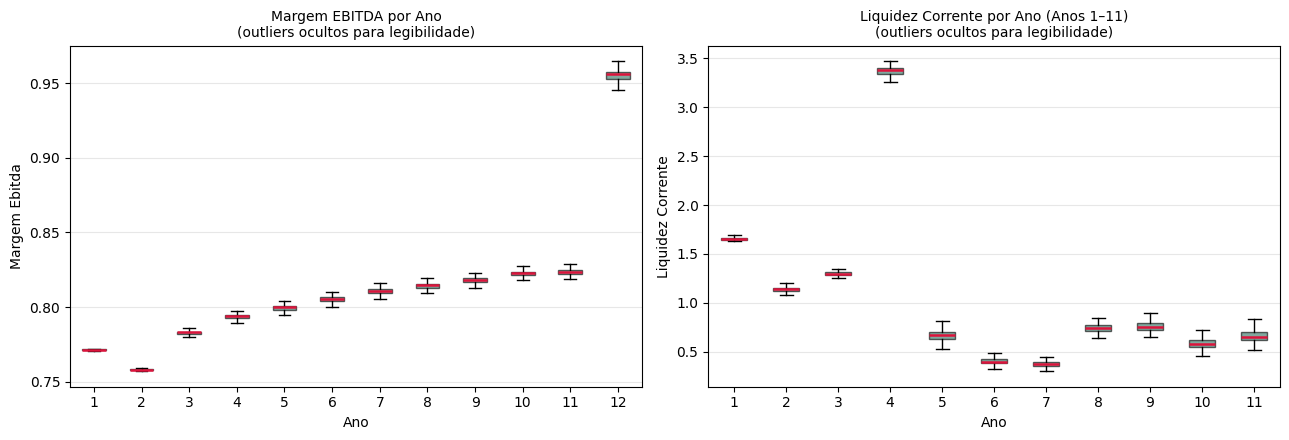

In [16]:
# Boxplot por ano — excluindo Ano 12 para os KPIs de liquidez (ver nota acima)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

configs = [
    ('margem_ebitda', 'Margem EBITDA por Ano', range(1, 13)),
    ('liquidez_corrente', 'Liquidez Corrente por Ano (Anos 1–11)', range(1, 12)),
]

for ax, (kpi, titulo, anos) in zip(axes, configs):
    dados = [w[w['ano_num'] == a][kpi].dropna() for a in anos]
    bp = ax.boxplot(dados, tick_labels=list(anos), showfliers=False,
                    patch_artist=True, medianprops=dict(color='crimson', linewidth=1.8))
    for caixa in bp['boxes']:
        caixa.set_facecolor('#2E6F5E')
        caixa.set_alpha(0.6)
    ax.set_title(titulo + '\n(outliers ocultos para legibilidade)', fontsize=10)
    ax.set_xlabel('Ano')
    ax.set_ylabel(kpi.replace('_', ' ').title())
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [17]:
# Liquidez Corrente no Ano 12, isolada e com estatística robusta (mediana em vez de média)
liquidez_ano12 = w[w['ano_num'] == 12]['liquidez_corrente']

print("Liquidez Corrente — Ano 12 (encerramento da concessão):")
print(liquidez_ano12.describe())
print()
print("Mediana (mais robusta que a média nesse caso):", liquidez_ano12.median())

Liquidez Corrente — Ano 12 (encerramento da concessão):
count     1200.000000
mean        50.085292
std        903.841345
min         -0.179987
25%          4.013504
50%          6.643819
75%         18.891354
max      31262.749850
Name: liquidez_corrente, dtype: float64

Mediana (mais robusta que a média nesse caso): 6.643818831406717


## 9. Classificação dos cenários (rascunho inicial)

A CTI sugeriu classificar os 1.200 cenários em 6 categorias. Esta é uma **primeira versão baseada em regras simples** (usando os percentis já calculados como limiares) — pode evoluir para clustering (ex.: k-means) mais adiante.

Categorias sugeridas pela CTI:
1. Alta rentabilidade e alta liquidez
2. Alta rentabilidade e baixa liquidez
3. Retorno moderado e baixo risco
4. Forte pressão de investimentos
5. Elevada distribuição e baixa disponibilidade
6. Encerramento com caixa insuficiente (aplica-se ao Ano 12)

> Obs: Os limiares abaixo (ex.: "alta" = acima do P75) são um ponto de partida definido pelo grupo NOUR!

In [18]:
def classificar_cenario(row):
    alta_rentab = row['margem_ebitda'] >= row['margem_ebitda_p75']
    alta_liquidez = row['liquidez_corrente'] >= row['liquidez_corrente_p75']
    baixa_liquidez = row['liquidez_corrente'] <= row['liquidez_corrente_p25']

    if row['encerramento_concessao'] and row['BAL - Disponível'] < 0:
        return 'Encerramento com caixa insuficiente'
    if alta_rentab and alta_liquidez:
        return 'Alta rentabilidade e alta liquidez'
    if alta_rentab and baixa_liquidez:
        return 'Alta rentabilidade e baixa liquidez'
    if not alta_rentab and not baixa_liquidez:
        return 'Retorno moderado e baixo risco'
    return 'Outros / a refinar'

# Calcular limiares (P25/P75) por ano, já que a distribuição muda ano a ano
for kpi in ['margem_ebitda', 'liquidez_corrente']:
    w[f'{kpi}_p75'] = w.groupby('ano_num')[kpi].transform(lambda x: x.quantile(0.75))
    w[f'{kpi}_p25'] = w.groupby('ano_num')[kpi].transform(lambda x: x.quantile(0.25))

w['categoria_cenario'] = w.apply(classificar_cenario, axis=1)
w['categoria_cenario'].value_counts()

,count
categoria_cenario,
Retorno moderado e baixo risco,8222
Outros / a refinar,4530
Alta rentabilidade e baixa liquidez,1021
Alta rentabilidade e alta liquidez,626
Encerramento com caixa insuficiente,1


## 10. Perspectivas de stakeholder

### Análise: risco de liquidez sob a ótica do CFO

Aqui vamos olhar exclusivamente para a Liquidez Corrente (capacidade de pagar obrigações de curto prazo com ativos de curto prazo), nos Anos 1 a 11 — é a pergunta que mais interessa a um CFO: **em quantos cenários a empresa corre risco de não conseguir cobrir suas obrigações de curto prazo?** Marcamos o limite crítico (liquidez = 1) para tornar visível de imediato quantos cenários ficam abaixo dessa linha de segurança.

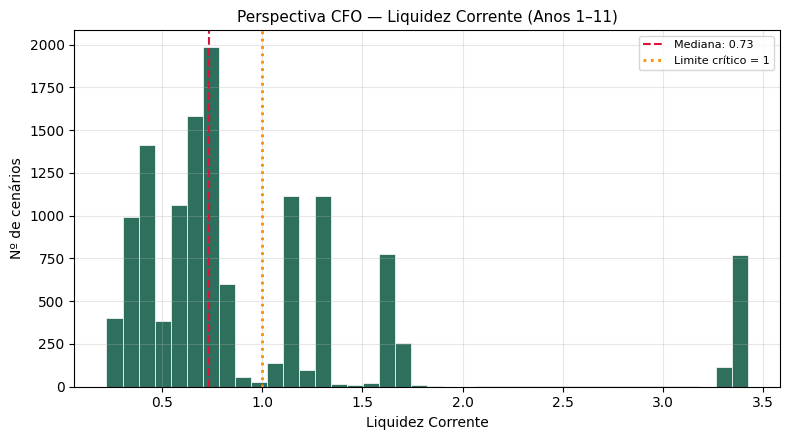

In [19]:
# CFO: risco de liquidez (Anos 1-11, já que o Ano 12 tem outra leitura)
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_hist(w[w['ano_num'].between(1, 11)]['liquidez_corrente'], ax,
          'Perspectiva CFO — Liquidez Corrente (Anos 1–11)', 'Liquidez Corrente')
ax.axvline(1, color='darkorange', ls=':', lw=2, label='Limite crítico = 1')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Análise: qual o endividamento nos piores cenários, do ponto de vista de um credor?

Um credor se importa menos com a média e mais com os piores casos. Aqui vamos olhar o Endividamento Geral sob essa ótica: **qual o nível de endividamento nos cenários mais alavancados (P90, P95) em cada ano, e isso representa um risco de crédito relevante?**

In [20]:
# Credores: percentis de endividamento por ano
w.groupby('ano_num')['endividamento_geral'].quantile([0.05, 0.10, 0.50, 0.90, 0.95]).unstack().round(3)

,0.05,0.10,0.50,0.90,0.95
ano_num,,,,,
1,0.809,0.810,0.812,0.820,0.820
2,0.856,0.858,0.861,0.883,0.883
3,0.856,0.858,0.862,0.892,0.892
4,0.829,0.830,0.835,0.870,0.870
5,0.971,0.971,1.092,1.105,1.108
6,1.128,1.128,1.269,1.287,1.290
7,1.303,1.303,1.394,1.416,1.420
8,1.277,1.288,1.322,1.340,1.342
9,1.349,1.363,1.417,1.590,1.590


### Análise: suficiência de caixa no encerramento da concessão

Aqui vamos analisar exclusivamente o Ano 12 (encerramento), sob a ótica do poder concedente — o órgão público que retoma a operação ao fim do contrato. A pergunta: **em quantos dos 1.200 cenários a empresa termina a concessão com caixa insuficiente para honrar suas obrigações finais?** Isso é relevante porque o encerramento envolve devolução de ativos, liquidação de dívidas e destinação do caixa remanescente — um caixa negativo nesse momento indicaria risco para essa transição.

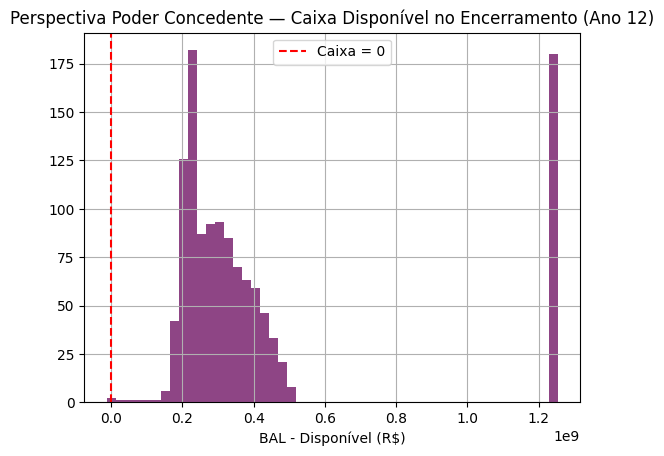

% de cenários com caixa negativo no encerramento: 0.08%


In [21]:
# Poder concedente: distribuição do caixa disponível no encerramento (Ano 12)
w[w['ano_num'] == 12]['BAL - Disponível'].hist(bins=50, color='#8E4585')
plt.title('Perspectiva Poder Concedente — Caixa Disponível no Encerramento (Ano 12)')
plt.xlabel('BAL - Disponível (R$)')
plt.axvline(0, color='red', linestyle='--', label='Caixa = 0')
plt.legend()
plt.show()

pct_caixa_insuficiente = (w[w['ano_num'] == 12]['BAL - Disponível'] < 0).mean()
print(f"% de cenários com caixa negativo no encerramento: {pct_caixa_insuficiente:.2%}")

## 11. Sinal de dificuldade financeira ("falência" — proxy)

### Análise: quais cenários mostram sinais de fragilidade financeira?

Aqui vamos identificar, dentro dos 1.200 cenários, quais apresentam algum sinal de fragilidade — mesmo que a empresa não entre tecnicamente em processo de falência. A pergunta: **em quantos cenários e em quais anos aparecem sinais como patrimônio líquido negativo ou caixa insuficiente, e esse risco aumenta conforme a concessão se aproxima do encerramento?**

Como não existe uma conta "falência" pronta na base — construímos um proxy combinando 3 critérios (conforme decidido):
1. **Patrimônio Líquido negativo em termos reais** — nesta base o PL normal vem armazenado como valor NEGATIVO; se o valor armazenado vira POSITIVO, significa que o patrimônio líquido real é negativo (passivo a descoberto).
2. **Caixa insuficiente** — `BAL - Disponível` negativo.
3. **Prejuízo persistente** — `DRE - Resultado Líquido` negativo.

> Achado: no teste, o Resultado Líquido nunca é negativo em nenhum dos 14.400 casos (a concessão é lucrativa em 100% dos cenários simulados) — então o critério 3 não deve disparar sozinho, mas mantemos no código por completude/robustez metodológica.

In [22]:
w['flag_pl_negativo_real'] = w['BAL - Patrimônio Líquido'] > 0 # sinal invertido nesta base
w['flag_caixa_negativo'] = w['BAL - Disponível'] < 0
w['flag_prejuizo'] = w['DRE - Resultado Líquido'] < 0

w['sinal_dificuldade_financeira'] = (
    w['flag_pl_negativo_real'] | w['flag_caixa_negativo'] | w['flag_prejuizo']
)

resumo_dificuldade = w.groupby('ano_num')['sinal_dificuldade_financeira'].mean() * 100
print("% de cenários com sinal de dificuldade financeira, por ano:")
print(resumo_dificuldade.round(2))

% de cenários com sinal de dificuldade financeira, por ano:
ano_num
1     0.00
2     0.00
3     0.00
4     0.00
5     0.00
6     0.25
7     0.58
8     0.83
9     1.00
10    1.25
11    1.33
12    0.08
Name: sinal_dificuldade_financeira, dtype: float64


## 12. WACC — abordagem híbrida

Aqui vamos estimar a taxa de desconto (WACC) usada nas próximas seções (EVA e Valuation) para trazer fluxos de caixa futuros a valor presente. Diferente das seções anteriores, esta etapa não analisa os cenários da CTI diretamente — usa a própria base para estimar um dos parâmetros (custo da dívida) e combina isso com uma referência externa de mercado para o custo do capital próprio.

Como a CTI não é uma empresa listada (sem beta ou preço de mercado próprio), usamos:
- **Kd** (custo da dívida): calculado direto da base — `Despesas Financeiras / Dívida Bruta`, tomando o Ano 1 como referência "atual"
- **Ke** (custo do capital próprio): via CAPM simplificado — taxa livre de risco (Selic) + β × prêmio de risco de mercado
- **Alíquota efetiva**: calculada da base (`Imposto de Renda e CSLL / Resultado Antes do IR`) — deu ~34,4%, muito próxima da alíquota legal brasileira (34%), o que é uma boa validação da base

**Parâmetros com fonte externa (ainda placeholder — ajustar quando coletarmos Selic/Focus):**
- Taxa livre de risco: Selic atual (~10,5% a.a. — ajustar com dado real do Focus/BCB)
- Prêmio de risco de mercado: ~5% (referência de mercado, ex. Damodaran para Brasil)
- Beta do setor: 0,6 (setor regulado/concessão, risco sistemático baixo — referência da literatura de WACC regulatório ANEEL/ANTT)

O WACC resultante (~7,5% real, após impostos) — bom sinal de sanidade.

In [23]:
# Kd: custo da dívida, direto da base
kd_por_ano = (w['DRE - Despesas Financeiras'].abs() / w['divida_bruta']).groupby(w['ano_num']).mean()
KD = kd_por_ano.loc[1]  # Ano 1 como referência "atual"

# Alíquota efetiva
ALIQUOTA_EFETIVA = (
    w['DRE - Imposto de Renda e Contribuição Social'].abs() / w['DRE - Resultado Antes do Imposto de Renda']
).mean()

# Ke via CAPM (parâmetros a validar com Selic/Focus real)
SELIC_LIVRE_RISCO = 0.105      # TO DO @Analice ou @Mariah: temos q substituir por valor real coletado (Focus/BCB)
PREMIO_RISCO_MERCADO = 0.05    # referência de mercado (Damodaran Brasil)
BETA_SETOR = 0.6               # setor regulado/concessão

KE = SELIC_LIVRE_RISCO + BETA_SETOR * PREMIO_RISCO_MERCADO

# Estrutura de capital (pesos), no Ano 1
divida_ano1 = w[w['ano_num'] == 1]['divida_bruta'].mean()
pl_ano1 = w[w['ano_num'] == 1]['BAL - Patrimônio Líquido'].abs().mean()
total_capital = divida_ano1 + pl_ano1
PESO_DIVIDA, PESO_PL = divida_ano1 / total_capital, pl_ano1 / total_capital

WACC = PESO_PL * KE + PESO_DIVIDA * KD * (1 - ALIQUOTA_EFETIVA)

print(f"Kd: {KD:.2%}  |  Ke: {KE:.2%}  |  Alíquota efetiva: {ALIQUOTA_EFETIVA:.2%}")
print(f"Peso Dívida: {PESO_DIVIDA:.2%}  |  Peso PL: {PESO_PL:.2%}")
print(f"WACC estimado: {WACC:.2%}")

Kd: 11.57%  |  Ke: 13.50%  |  Alíquota efetiva: 34.38%
Peso Dívida: 74.89%  |  Peso PL: 25.11%
WACC estimado: 9.08%


## 13. EVA (Valor Econômico Agregado)

Diferente das margens (que olham a rentabilidade só em relação à receita), o EVA considera o quanto de capital foi necessário para gerar aquele resultado. Aqui vamos verificar: **em cada cenário e ano, o resultado operacional supera o custo do capital investido, ou fica abaixo dele?**

`EVA = NOPAT − (Capital Investido × WACC)`, calculado para cada combinação ano × cenário.
- `NOPAT` = Resultado Operacional × (1 − alíquota efetiva)
- `Capital Investido` = Dívida Bruta + Patrimônio Líquido (em módulo)

In [24]:
w['capital_investido'] = w['divida_bruta'] + w['BAL - Patrimônio Líquido'].abs()
w['nopat'] = w['DRE - Resultado Operacional'] * (1 - ALIQUOTA_EFETIVA)
w['eva'] = w['nopat'] - WACC * w['capital_investido']

print("EVA médio por ano (R$):")
print(w.groupby('ano_num')['eva'].mean())

EVA médio por ano (R$):
ano_num
1     2.068829e+09
2     1.646689e+09
3     1.763331e+09
4     1.842241e+09
5     1.977071e+09
6     2.106586e+09
7     2.175130e+09
8     2.368568e+09
9     2.548182e+09
10    2.874966e+09
11    3.260481e+09
12             NaN
Name: eva, dtype: float64


## 14. Valuation (VPL) e MVA — distribuição de valor entre os cenários, sob a ótica do acionista

Aqui vamos analisar como o Valuation (VPL das distribuições de caixa ao acionista, descontadas pelo WACC) se distribui entre os 1.200 cenários. A pergunta: **o valor gerado para o acionista é parecido em praticamente todos os futuros simulados, ou existem cenários que geram muito mais (ou muito menos) valor que a maioria?** Essa distribuição ajuda a entender o risco associado ao retorno do investimento na concessão, não só o seu valor médio.

Testamos duas variáveis de fluxo de caixa para o VPL: `FLU - Geração de Caixa` (caixa retido internamente) e `FLU - Distribuição para Acionista` (o que efetivamente sai da empresa pro acionista). A primeira gerou um MVA fortemente negativo, incoerente com as margens altas observadas — optamos por `FLU - Distribuição para Acionista`, que é a medida correta de fluxo de caixa **para o acionista** (a base do valuation de equity), e o resultado ficou consistente (MVA positivo).

`MVA = VPL (valor presente das distribuições futuras) − Capital Investido inicial (Ano 1)`

Valuation (VPL) entre os 1.200 cenários:
count    1.200000e+03
mean     2.147706e+10
std      2.812876e+08
min      2.069439e+10
25%      2.145640e+10
50%      2.152542e+10
75%      2.160582e+10
max      2.372354e+10
dtype: float64

MVA entre os 1.200 cenários:
count    1.200000e+03
mean     1.356276e+10
std      2.488835e+08
min      1.299868e+10
25%      1.353534e+10
50%      1.359984e+10
75%      1.367040e+10
max      1.578059e+10
dtype: float64


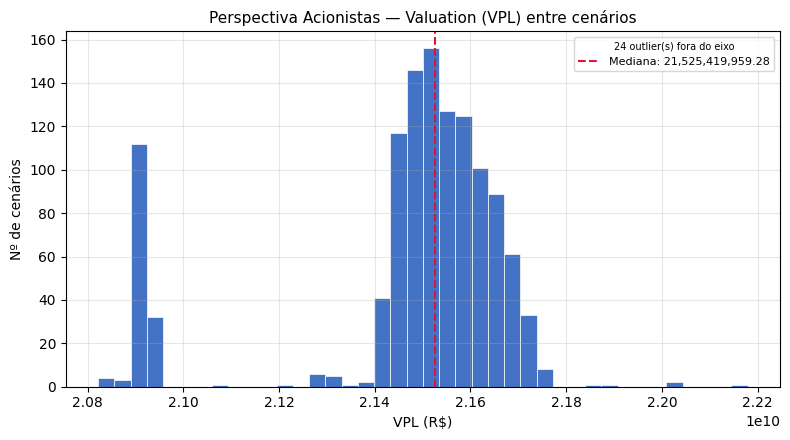

In [25]:
def calcular_vpl_cenario(grupo):
    grupo = grupo.sort_values('ano_num')
    fluxos = grupo['FLU - Distribuição para Acionista'].abs().values
    anos = grupo['ano_num'].values
    return np.sum(fluxos / (1 + WACC) ** anos)

vpl_por_cenario = w.groupby('Cenário').apply(calcular_vpl_cenario, include_groups=False)
capital_investido_ano1 = w[w['ano_num'] == 1].set_index('Cenário')['capital_investido']
mva_por_cenario = vpl_por_cenario - capital_investido_ano1

print("Valuation (VPL) entre os 1.200 cenários:")
print(vpl_por_cenario.describe())
print("\nMVA entre os 1.200 cenários:")
print(mva_por_cenario.describe())

# Histograma (perspectiva acionistas)
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_hist(vpl_por_cenario, ax,
          'Perspectiva Acionistas — Valuation (VPL) entre cenários',
          'VPL (R$)', cor='#4472C4')
plt.tight_layout()
plt.show()

## 15. Framework genérico: "em X% dos cenários, Y acontece no Ano Z"

### Análise: construindo uma ferramenta genérica de "em X% dos cenários, Y acontece"

Em vez de escrever um cálculo específico para cada pergunta de probabilidade, aqui vamos construir uma função reutilizável e testá-la com três exemplos concretos: dificuldade financeira, alavancagem excessiva acima de um limite, e queda de margem em relação ao ano anterior.

In [26]:
def probabilidade_evento(dados, condicao, por_ano=True):
    """
    condicao: função que recebe o DataFrame e devolve uma Series booleana (True = evento ocorreu)
    por_ano=True: retorna % por ano | False: retorna % agregado em toda a base
    """
    flag = condicao(dados)
    if por_ano:
        return (flag.groupby(dados['ano_num']).mean() * 100).round(2)
    return round(flag.mean() * 100, 2)

# Exemplos de uso
print("% cenários com sinal de dificuldade financeira, por ano:")
print(probabilidade_evento(w, lambda d: d['sinal_dificuldade_financeira']))

print("\n% cenários com endividamento (Dívida Líquida/EBITDA) acima de 3x, por ano:")
print(probabilidade_evento(w, lambda d: d['divida_liquida_ebitda'] > 3))

print("\n% cenários com queda de margem EBITDA em relação ao ano anterior:")
w_sorted = w.sort_values(['Cenário', 'ano_num'])
w_sorted['margem_ebitda_anterior'] = w_sorted.groupby('Cenário')['margem_ebitda'].shift(1)
print(probabilidade_evento(w_sorted, lambda d: d['margem_ebitda'] < d['margem_ebitda_anterior']))

% cenários com sinal de dificuldade financeira, por ano:
ano_num
1     0.00
2     0.00
3     0.00
4     0.00
5     0.00
6     0.25
7     0.58
8     0.83
9     1.00
10    1.25
11    1.33
12    0.08
Name: sinal_dificuldade_financeira, dtype: float64

% cenários com endividamento (Dívida Líquida/EBITDA) acima de 3x, por ano:
ano_num
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
Name: divida_liquida_ebitda, dtype: float64

% cenários com queda de margem EBITDA em relação ao ano anterior:
ano_num
1       0.00
2     100.00
3       0.00
4       0.00
5       0.00
6       0.00
7       0.00
8       0.00
9       0.00
10      0.00
11      0.25
12      0.00
dtype: float64
